# ML 모델 최적화 비교 — 10분 전력 데이터 기반 단기 예측

**데이터**: ~/data/KIER_3_Temporal_Resolution/seasonal_naive/KIER_USAGE_ELEC_INST_INTERP_10MIN.csv`  
**모델**: CatBoost · Decision Tree · LightGBM · RandomForest · XGBoost  
**HPO**: `RandomizedSearchCV` + `TimeSeriesSplit(n_splits=3)` — 세대별 최적 하이퍼파라미터 탐색  
**예측**: 단일 세대별 10분 후 전력 소비량 (1-step ahead)  
**평가 지표**: MAE · RMSE · MAPE · R²  
**결과 저장**: `results/models/`

---

| 항목 | 설정 |
|---|---|
| 입력 특징 | 래그 피처 13개 + 롤링 통계 4개 + 시간 특징 6개 = 23개 |
| 예측 horizon | 1 스텝 (10분 후) |
| Train / Test | 85 / 15 % (시간순 분할) |
| HPO CV | TimeSeriesSplit(n_splits=3), n_iter=30 |
| 세대 샘플 수 | 10개 (CFG에서 조정) |

In [1]:
# ── 00. Configuration ────────────────────────────────────────────────────────
from pathlib import Path

CFG = {
    'data_path'     : str(Path.home() / 'data' / 'KIER_3_Temporal_Resolution' / 'seasonal_naive' / 'KIER_USAGE_ELEC_INST_INTERP_10MIN.csv'),
    'n_households'  : 10,
    'seed'          : 42,
    'test_ratio'    : 0.15,
    # HPO
    'n_iter'        : 30,          # RandomizedSearchCV 탐색 횟수
    'cv_splits'     : 3,           # TimeSeriesSplit 분할 수
    'scoring'       : 'neg_root_mean_squared_error',
    'n_jobs'        : -1,          # 병렬 CPU 코어 수
    # 출력
    'results_dir'   : '../results/models/',
}

In [2]:
# ── 01. Imports ───────────────────────────────────────────────────────────────
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from pprint import pformat

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import xgboost as xgb

warnings.filterwarnings('ignore')
np.random.seed(CFG['seed'])

RESULTS_DIR = Path(CFG['results_dir'])
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Imports OK")

Imports OK


## 02. 데이터 로드

In [3]:
raw = pd.read_csv(CFG['data_path'], parse_dates=['METER_DATE'], index_col='METER_DATE').sort_index()
print(f"기간 : {raw.index[0]}  →  {raw.index[-1]}")
print(f"행수 : {len(raw):,}   세대 수: {raw.shape[1]}")

rng = np.random.default_rng(CFG['seed'])
complete_cols = [c for c in raw.columns if raw[c].isna().sum() == 0]
selected_cols = list(rng.choice(complete_cols, size=CFG['n_households'], replace=False))
print(f"선택 세대: {selected_cols}")

기간 : 2022-07-17 23:00:00  →  2024-06-05 15:30:00
행수 : 97,438   세대 수: 348
선택 세대: [np.str_('ELEC_1-8-2'), np.str_('ELEC_3-9-6'), np.str_('ELEC_1-8-3'), np.str_('ELEC_3-3-2'), np.str_('ELEC_2-14-1'), np.str_('ELEC_2-13-5'), np.str_('ELEC_3-6-2'), np.str_('ELEC_1-9-1'), np.str_('ELEC_1-18-2'), np.str_('ELEC_3-15-2')]


## 03. 특징 공학 (래그 · 롤링 · 시간)

트리 기반 ML 모델은 시퀀스 입력 대신 **래그 피처** + **롤링 통계** + **시간 인코딩**을 사용합니다.

| 피처 그룹 | 변수 | 개수 |
|---|---|---|
| 단기 래그 | lag_1 ~ lag_6 (10~60분) | 6 |
| 중기 래그 | lag_12, lag_18, lag_24, lag_36, lag_48 | 5 |
| 일간 래그 | lag_144 (24H 전), lag_288 (48H 전) | 2 |
| 롤링 통계 | rolling_mean_12, rolling_mean_144, rolling_std_12, rolling_std_144 | 4 |
| 시간 인코딩 | hour/dow/month × sin·cos | 6 |
| **합계** | | **23** |

In [4]:
LAG_SHORT  = [1, 2, 3, 4, 5, 6]         # 10~60분
LAG_MID    = [12, 18, 24, 36, 48]        # 2H~8H
LAG_DAILY  = [144, 288]                  # 24H, 48H
ROLL_WIN   = [12, 144]                   # 2H, 24H 롤링


def build_ml_features(series: pd.Series) -> pd.DataFrame:
    """
    단일 세대 시계열 → ML 피처 DataFrame.
    반환: [energy, lag_*, rolling_*, time_*] 컬럼 + NaN 행 제거.
    """
    df = pd.DataFrame({'energy': series})

    # 래그 피처
    for lag in LAG_SHORT + LAG_MID + LAG_DAILY:
        df[f'lag_{lag}'] = df['energy'].shift(lag)

    # 롤링 통계
    for w in ROLL_WIN:
        df[f'rolling_mean_{w}'] = df['energy'].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}']  = df['energy'].shift(1).rolling(w).std()

    # 시간 인코딩
    idx = df.index
    df['hour_sin']  = np.sin(2 * np.pi * idx.hour / 24)
    df['hour_cos']  = np.cos(2 * np.pi * idx.hour / 24)
    df['dow_sin']   = np.sin(2 * np.pi * idx.dayofweek / 7)
    df['dow_cos']   = np.cos(2 * np.pi * idx.dayofweek / 7)
    df['month_sin'] = np.sin(2 * np.pi * idx.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * idx.month / 12)

    df = df.dropna()
    return df


def split_xy(df: pd.DataFrame, test_ratio: float):
    """시간순 Train/Test 분할 → X_tr, y_tr, X_te, y_te."""
    n_test = int(len(df) * test_ratio)
    train, test = df.iloc[:-n_test], df.iloc[-n_test:]
    feat_cols = [c for c in df.columns if c != 'energy']
    return (train[feat_cols].values, train['energy'].values,
            test[feat_cols].values,  test['energy'].values)


# 피처 수 확인
_df_ex = build_ml_features(raw[selected_cols[0]])
FEAT_COLS = [c for c in _df_ex.columns if c != 'energy']
print(f"피처 수: {len(FEAT_COLS)}")
print(f"피처 목록: {FEAT_COLS}")

피처 수: 23
피처 목록: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_12', 'lag_18', 'lag_24', 'lag_36', 'lag_48', 'lag_144', 'lag_288', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_144', 'rolling_std_144', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## 04. HPO 탐색 공간 정의

In [5]:
from scipy.stats import randint, uniform

PARAM_SPACES = {
    'CatBoost': {
        'iterations'    : randint(300, 1001),
        'depth'         : randint(4, 9),
        'learning_rate' : uniform(0.01, 0.14),   # [0.01, 0.15)
        'l2_leaf_reg'   : randint(1, 8),
        'bagging_temperature': uniform(0, 1),
        'random_strength'    : uniform(0, 2),
    },
    'DecisionTree': {
        'max_depth'        : [4, 6, 8, 10, 12, None],
        'min_samples_split': randint(2, 21),
        'min_samples_leaf' : randint(1, 17),
        'max_features'     : ['sqrt', 'log2', None, 0.5, 0.7],
    },
    'LightGBM': {
        'n_estimators'    : randint(200, 1001),
        'learning_rate'   : uniform(0.005, 0.145),
        'num_leaves'      : randint(20, 128),
        'max_depth'       : [-1, 5, 7, 9, 11],
        'min_child_samples': randint(10, 101),
        'subsample'       : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha'       : uniform(0, 0.5),
        'reg_lambda'      : uniform(0, 0.5),
    },
    'RandomForest': {
        'n_estimators'    : randint(100, 401),
        'max_depth'       : [5, 8, 12, 16, None],
        'min_samples_split': randint(2, 21),
        'min_samples_leaf' : randint(1, 17),
        'max_features'    : ['sqrt', 'log2', 0.3, 0.5, 0.7],
    },
    'XGBoost': {
        'n_estimators'    : randint(200, 1001),
        'max_depth'       : randint(3, 9),
        'learning_rate'   : uniform(0.01, 0.14),
        'subsample'       : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha'       : uniform(0, 0.5),
        'reg_lambda'      : uniform(0.5, 1.5),
        'min_child_weight': randint(1, 11),
    },
}

BASE_MODELS = {
    'CatBoost'    : CatBoostRegressor(random_seed=CFG['seed'], verbose=0,
                                      od_type='Iter', od_wait=20),
    'DecisionTree': DecisionTreeRegressor(random_state=CFG['seed']),
    'LightGBM'    : LGBMRegressor(random_state=CFG['seed'], verbose=-1),
    'RandomForest': RandomForestRegressor(random_state=CFG['seed'], n_jobs=1),
    'XGBoost'     : xgb.XGBRegressor(random_state=CFG['seed'], tree_method='hist',
                                      verbosity=0),
}

print("HPO 탐색 공간 정의 완료:", list(PARAM_SPACES.keys()))

HPO 탐색 공간 정의 완료: ['CatBoost', 'DecisionTree', 'LightGBM', 'RandomForest', 'XGBoost']


## 05. 최적화 + 학습 루프 — 세대별 × 모델별

In [6]:
def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100


def compute_metrics(y_true, y_pred):
    return {
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'RMSE' : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE' : mape(y_true, y_pred),
        'R2'   : r2_score(y_true, y_pred),
    }


def run_hpo_and_eval(X_tr, y_tr, X_te, y_te, model_name: str):
    """
    RandomizedSearchCV로 최적 파라미터 탐색 → 전체 훈련 데이터로 재학습 → 테스트 평가.
    Returns: (metrics_dict, best_params, elapsed_s)
    """
    base_model  = BASE_MODELS[model_name]
    param_space = PARAM_SPACES[model_name]
    tscv        = TimeSeriesSplit(n_splits=CFG['cv_splits'])

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_space,
        n_iter=CFG['n_iter'],
        scoring=CFG['scoring'],
        cv=tscv,
        random_state=CFG['seed'],
        n_jobs=CFG['n_jobs'],
        refit=True,             # 최적 파라미터로 전체 훈련 데이터 재학습
        error_score='raise',
    )

    t0 = time.time()
    search.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred  = search.best_estimator_.predict(X_te)
    metrics = compute_metrics(y_te, y_pred)
    return metrics, search.best_params_, elapsed


# ── 본 실험 ───────────────────────────────────────────────────────────────────
records    = []
best_params_log = {}   # {(model, household): best_params}
sample_preds    = {}   # {model_name: (y_true, y_pred)} 마지막 세대

for col in tqdm(selected_cols, desc='Household'):
    feat_df = build_ml_features(raw[col])
    X_tr, y_tr, X_te, y_te = split_xy(feat_df, CFG['test_ratio'])

    for model_name in tqdm(BASE_MODELS.keys(), desc=f'  {col}', leave=False):
        metrics, best_params, elapsed = run_hpo_and_eval(X_tr, y_tr, X_te, y_te, model_name)

        records.append({
            'model'      : model_name,
            'household'  : col,
            'elapsed_s'  : round(elapsed, 1),
            **metrics,
        })
        best_params_log[(model_name, col)] = best_params

        if col == selected_cols[-1]:
            # 마지막 세대 예측 저장 (시각화용)
            from sklearn.base import clone
            final_m = clone(BASE_MODELS[model_name]).set_params(**best_params)
            final_m.fit(X_tr, y_tr)
            sample_preds[model_name] = (y_te, final_m.predict(X_te))

results_df = pd.DataFrame(records)
print("\n실험 완료  |  총 레코드:", len(results_df))

Household:   0%|          | 0/10 [00:00<?, ?it/s]

  ELEC_1-8-2:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/labq_s.h.ryu/WS_TimeSerial_ClusterBoost_Energy/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/labq_s.h.ryu/WS_TimeSerial_ClusterBoost_Energy/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/labq_s.h.ryu/WS_TimeSerial_ClusterBoost_Energy/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/Users/labq_s.h.ryu/WS_TimeSerial_ClusterBoost_Energy/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/labq_s.h.ryu/WS_TimeSerial_ClusterBoost_Energy/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/labq_s.h.ryu/WS_TimeSerial_ClusterBoost_Energy/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/Users/labq_s.h.ryu/WS_TimeSerial_ClusterBoost_Energy/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



실험 완료  |  총 레코드: 50


## 06. 성능 비교 집계

In [7]:
METRICS = ['MAE', 'RMSE', 'MAPE', 'R2']
MODEL_ORDER = list(BASE_MODELS.keys())

summary = results_df.groupby('model')[METRICS + ['elapsed_s']].agg(['mean', 'std'])
summary.columns = ['_'.join(c) for c in summary.columns]

display_rows = []
for m in MODEL_ORDER:
    r = summary.loc[m]
    display_rows.append({
        'Model'    : m,
        'MAE'      : f"{r['MAE_mean']:.4f} ± {r['MAE_std']:.4f}",
        'RMSE'     : f"{r['RMSE_mean']:.4f} ± {r['RMSE_std']:.4f}",
        'MAPE (%)' : f"{r['MAPE_mean']:.2f} ± {r['MAPE_std']:.2f}",
        'R²'       : f"{r['R2_mean']:.4f} ± {r['R2_std']:.4f}",
        'Time (s)' : f"{r['elapsed_s_mean']:.1f}",
    })

display_df = pd.DataFrame(display_rows).set_index('Model')
print("=== ML 모델 비교 결과 (HPO, 평균 ± 표준편차) ===")
display(display_df)

=== ML 모델 비교 결과 (HPO, 평균 ± 표준편차) ===


,MAE,RMSE,MAPE (%),R²,Time (s)
Model,,,,,
CatBoost,0.0215 ± 0.0031,0.0940 ± 0.0173,317344.54 ± 452099.74,0.1579 ± 0.0956,88.2
DecisionTree,0.0234 ± 0.0036,0.0947 ± 0.0167,350608.78 ± 490904.19,0.1440 ± 0.0848,2.5
LightGBM,0.0216 ± 0.0032,0.0935 ± 0.0171,308537.80 ± 420062.45,0.1656 ± 0.0953,250.6
RandomForest,0.0215 ± 0.0032,0.0935 ± 0.0171,314260.86 ± 446535.28,0.1664 ± 0.0941,713.6
XGBoost,0.0217 ± 0.0032,0.0938 ± 0.0173,315789.34 ± 429557.43,0.1605 ± 0.0955,24.5


In [8]:
# ── 종합 순위 ─────────────────────────────────────────────────────────────────
rank_df = pd.DataFrame(index=MODEL_ORDER)
for m in MODEL_ORDER:
    r = summary.loc[m]
    for met in METRICS:
        rank_df.loc[m, f'{met}_mean'] = r[f'{met}_mean']

rank_df['rank_MAE']  = rank_df['MAE_mean'].rank()
rank_df['rank_RMSE'] = rank_df['RMSE_mean'].rank()
rank_df['rank_MAPE'] = rank_df['MAPE_mean'].rank()
rank_df['rank_R2']   = rank_df['R2_mean'].rank(ascending=False)
rank_df['avg_rank']  = rank_df[['rank_MAE','rank_RMSE','rank_MAPE','rank_R2']].mean(axis=1)

print("=== 종합 순위 ===")
display(rank_df.sort_values('avg_rank')[['MAE_mean','RMSE_mean','MAPE_mean','R2_mean','avg_rank']])

=== 종합 순위 ===


,MAE_mean,RMSE_mean,MAPE_mean,R2_mean,avg_rank
RandomForest,0.021540,0.093495,314260.856372,0.166363,1.50
LightGBM,0.021563,0.093549,308537.800247,0.165564,2.00
CatBoost,0.021506,0.094003,317344.541013,0.157871,3.25
XGBoost,0.021710,0.093845,315789.341111,0.160497,3.25
DecisionTree,0.023384,0.094712,350608.779507,0.143994,5.00


In [9]:
# ── 세대 간 Best Params 최빈값 (참조용) ──────────────────────────────────────
print("=== 세대 간 HPO 결과 (모델별 대표 Best Params) ===")
representative_params = {}
for model_name in MODEL_ORDER:
    all_params = [best_params_log[(model_name, col)] for col in selected_cols]
    # 수치형 파라미터의 중앙값 계산
    keys = list(all_params[0].keys())
    rep  = {}
    for k in keys:
        vals = [p[k] for p in all_params]
        try:
            rep[k] = round(float(np.median([float(v) for v in vals])), 4)
        except (TypeError, ValueError):
            from collections import Counter
            rep[k] = Counter(vals).most_common(1)[0][0]
    representative_params[model_name] = rep
    print(f"\n  [{model_name}]")
    for k, v in rep.items():
        print(f"    {k}: {v}")

=== 세대 간 HPO 결과 (모델별 대표 Best Params) ===

  [CatBoost]
    bagging_temperature: 0.5643
    depth: 5.5
    iterations: 803.0
    l2_leaf_reg: 2.0
    learning_rate: 0.0262
    random_strength: 1.6533

  [DecisionTree]
    max_depth: 4.0
    max_features: 0.7
    min_samples_leaf: 15.0
    min_samples_split: 14.0

  [LightGBM]
    colsample_bytree: 0.8143
    learning_rate: 0.0181
    max_depth: -1.0
    min_child_samples: 82.0
    n_estimators: 323.0
    num_leaves: 78.0
    reg_alpha: 0.0933
    reg_lambda: 0.0204
    subsample: 0.8364

  [RandomForest]
    max_depth: None
    max_features: 0.5
    min_samples_leaf: 12.0
    min_samples_split: 14.5
    n_estimators: 228.5

  [XGBoost]
    colsample_bytree: 0.8426
    learning_rate: 0.0235
    max_depth: 7.0
    min_child_weight: 9.0
    n_estimators: 298.0
    reg_alpha: 0.3705
    reg_lambda: 0.9259
    subsample: 0.7221


## 07. 시각화

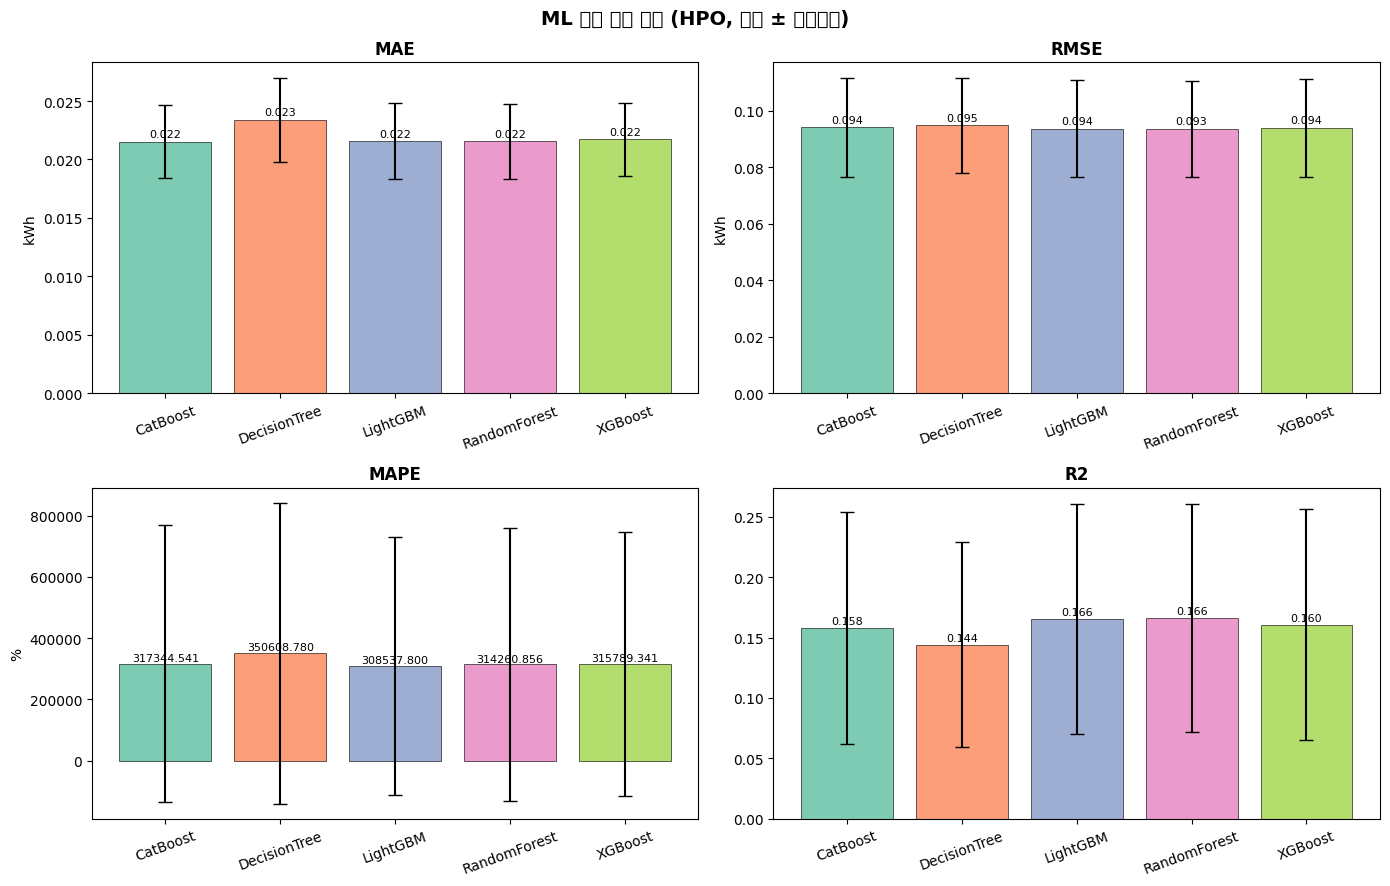

In [10]:
# ── 7-1. 지표별 Bar Chart ────────────────────────────────────────────────────
palette = sns.color_palette('Set2', n_colors=len(MODEL_ORDER))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('ML 모델 성능 비교 (HPO, 평균 ± 표준편차)', fontsize=14, fontweight='bold')

for ax, metric in zip(axes.ravel(), METRICS):
    means = [summary.loc[m, f'{metric}_mean'] for m in MODEL_ORDER]
    stds  = [summary.loc[m, f'{metric}_std']  for m in MODEL_ORDER]
    bars  = ax.bar(MODEL_ORDER, means, yerr=stds, capsize=5,
                   color=palette, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('kWh' if metric not in ('MAPE', 'R2') else
                  ('%' if metric == 'MAPE' else ''))
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'ml_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

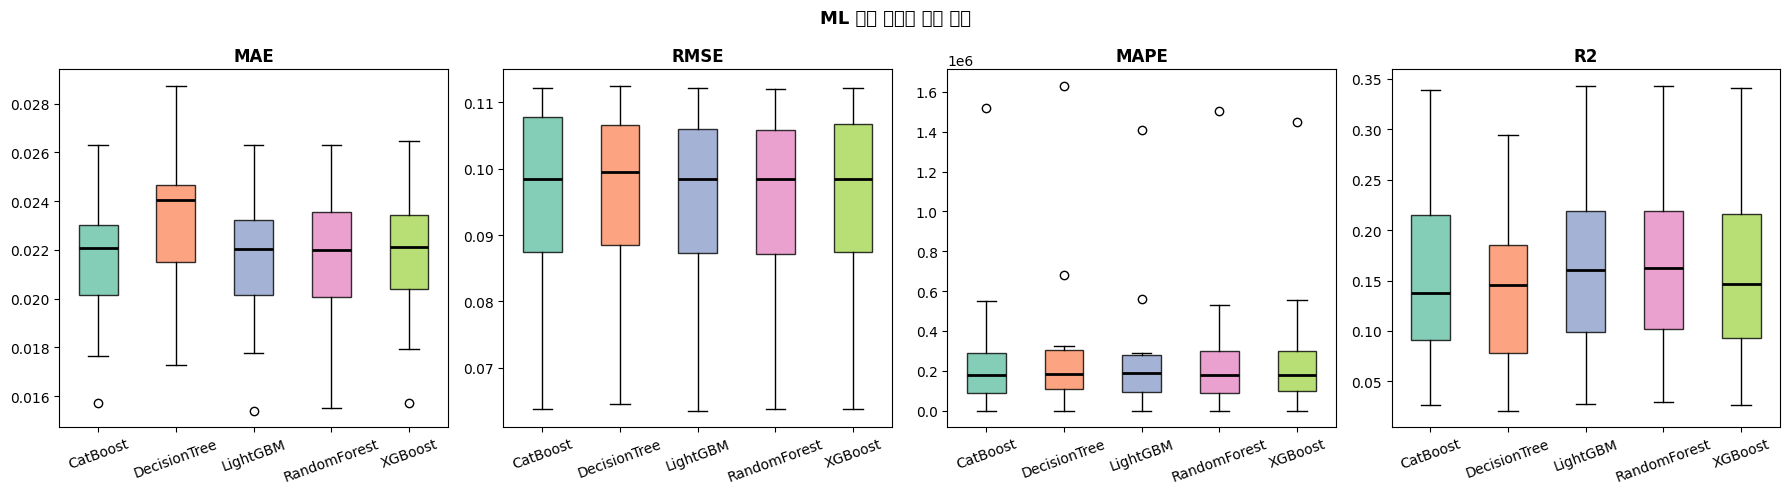

In [11]:
# ── 7-2. 세대별 성능 분포 Boxplot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('ML 모델 세대별 성능 분포', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, METRICS):
    data_per_model = [results_df[results_df['model'] == m][metric].values for m in MODEL_ORDER]
    bp = ax.boxplot(data_per_model, labels=MODEL_ORDER, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'ml_comparison_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

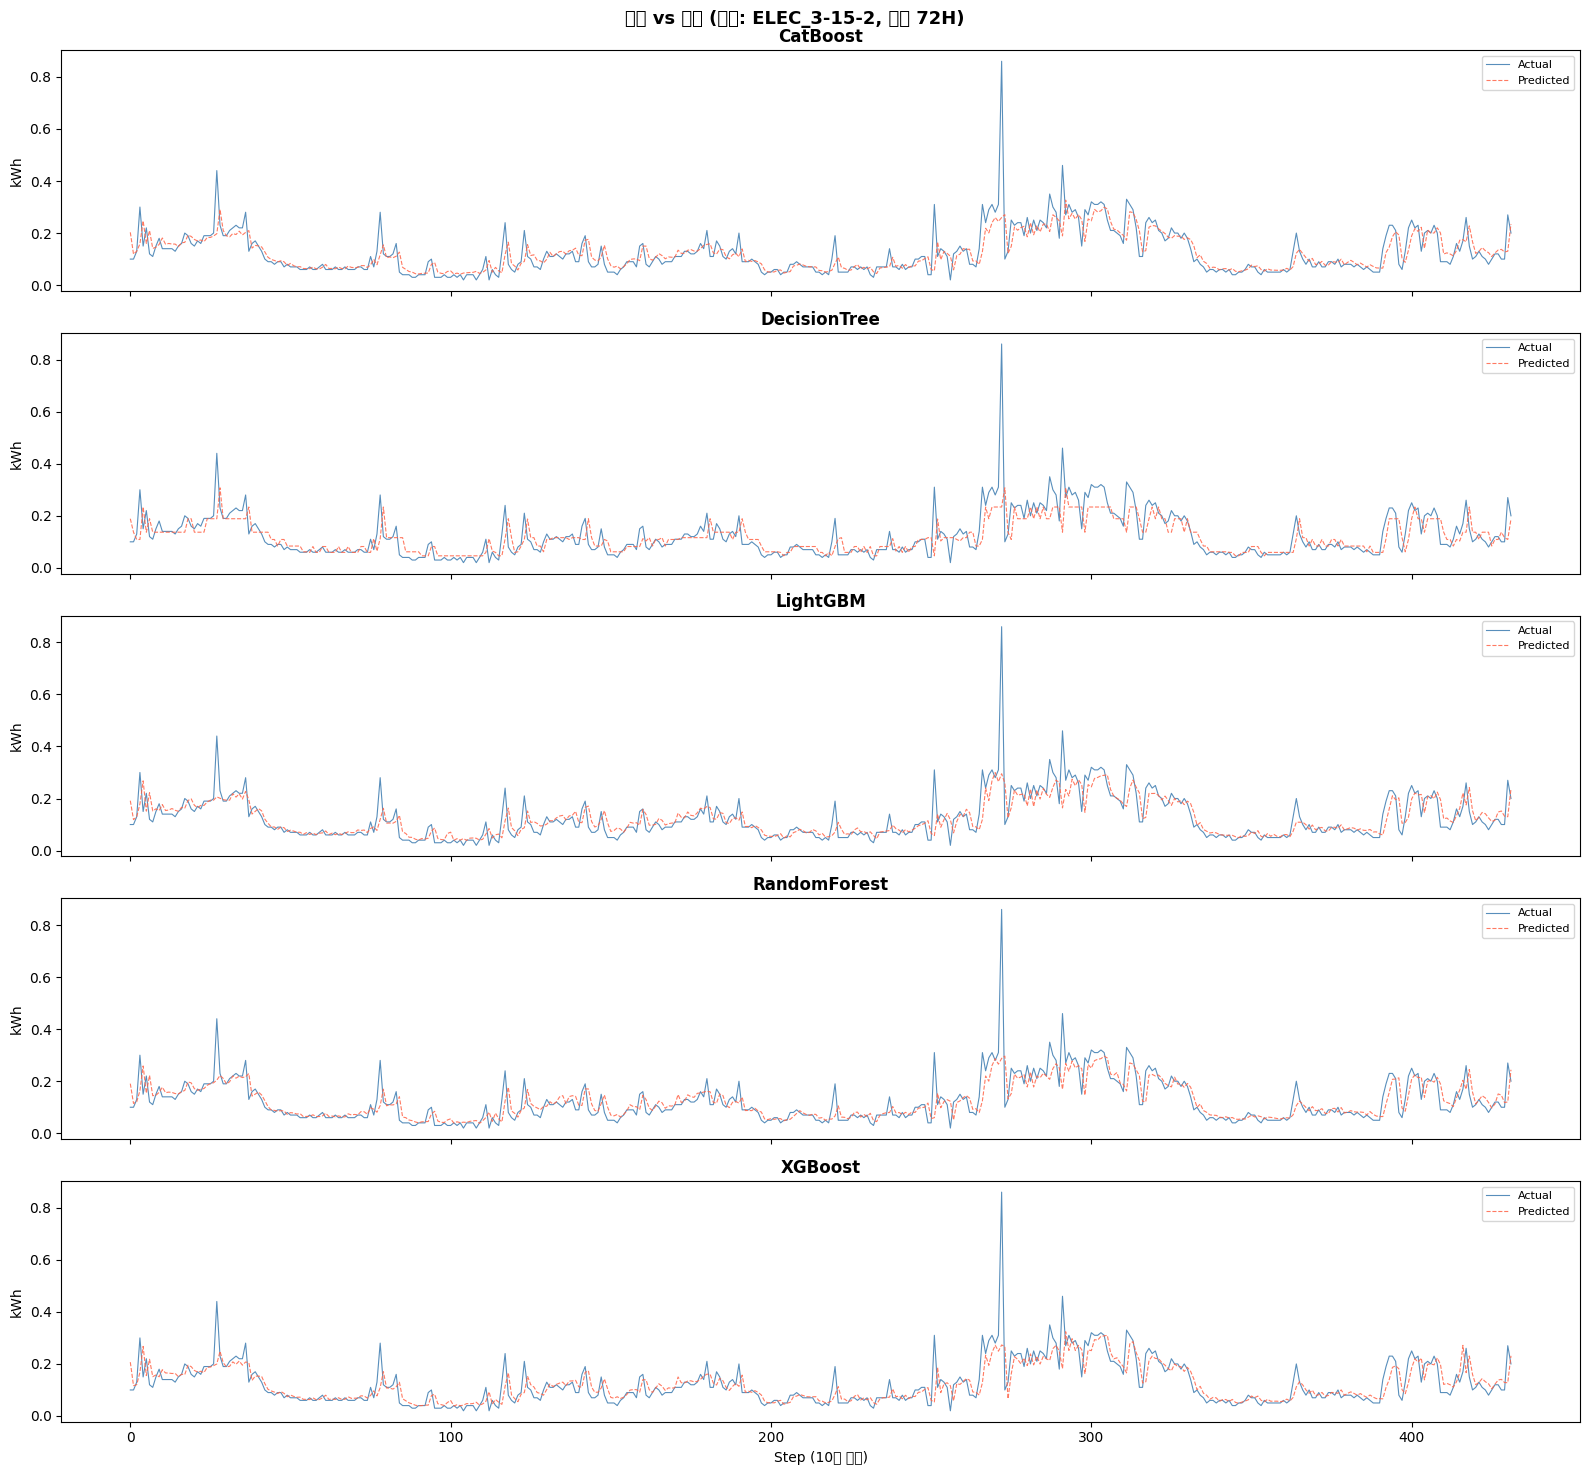

In [12]:
# ── 7-3. 예측 곡선 비교 (마지막 세대, 최초 72H) ─────────────────────────────────
PLOT_STEPS = 432

fig, axes = plt.subplots(len(MODEL_ORDER), 1, figsize=(16, 3 * len(MODEL_ORDER)), sharex=True)
fig.suptitle(f'예측 vs 실제 (세대: {selected_cols[-1]}, 최초 72H)', fontsize=13, fontweight='bold')

for ax, model_name in zip(axes, MODEL_ORDER):
    y_true, y_pred = sample_preds[model_name]
    n = min(PLOT_STEPS, len(y_true))
    ax.plot(y_true[:n], label='Actual',    color='steelblue', linewidth=0.8, alpha=0.9)
    ax.plot(y_pred[:n], label='Predicted', color='tomato',    linewidth=0.8, alpha=0.85, linestyle='--')
    ax.set_title(model_name, fontweight='bold')
    ax.set_ylabel('kWh')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Step (10분 단위)')
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'ml_comparison_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

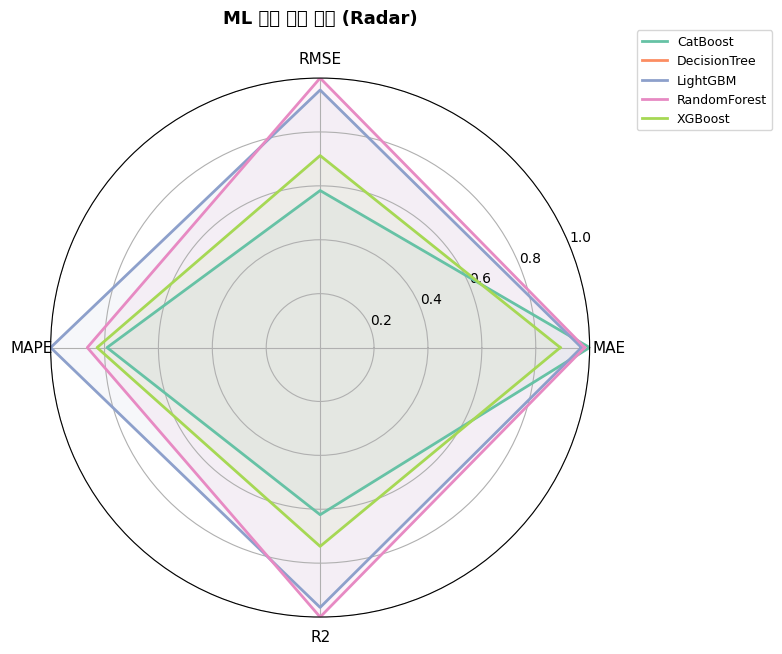

In [13]:
# ── 7-4. Radar Chart ─────────────────────────────────────────────────────────
radar_metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
N_met = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N_met, endpoint=False).tolist()
angles += angles[:1]

radar_arr = np.array([[summary.loc[m, f'{met}_mean'] for met in radar_metrics]
                       for m in MODEL_ORDER])
mins, maxs = radar_arr.min(axis=0), radar_arr.max(axis=0)
hib = [False, False, False, True]   # higher_is_better flags

def norm_val(v, lo, hi, h_better):
    if hi == lo: return 0.5
    return (v - lo)/(hi - lo) if h_better else 1 - (v - lo)/(hi - lo)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_title('ML 모델 종합 성능 (Radar)', fontsize=13, fontweight='bold', pad=20)

for idx, m in enumerate(MODEL_ORDER):
    vals = radar_arr[idx]
    nv   = [norm_val(vals[j], mins[j], maxs[j], hib[j]) for j in range(N_met)] + \
           [norm_val(vals[0], mins[0], maxs[0], hib[0])]
    ax.plot(angles, nv, linewidth=2, color=palette[idx], label=m)
    ax.fill(angles, nv, alpha=0.08, color=palette[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
fig.savefig(RESULTS_DIR / 'ml_comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 08. 결과 저장

In [14]:
# 세부 결과
results_df.to_csv(RESULTS_DIR / 'ml_comparison_detail.csv', index=False)

# 집계 결과
agg_out = []
for m in MODEL_ORDER:
    r = summary.loc[m]
    agg_out.append({
        'model'         : m,
        'MAE_mean'      : round(r['MAE_mean'],  4),
        'MAE_std'       : round(r['MAE_std'],   4),
        'RMSE_mean'     : round(r['RMSE_mean'], 4),
        'RMSE_std'      : round(r['RMSE_std'],  4),
        'MAPE_mean'     : round(r['MAPE_mean'], 2),
        'MAPE_std'      : round(r['MAPE_std'],  2),
        'R2_mean'       : round(r['R2_mean'],   4),
        'R2_std'        : round(r['R2_std'],    4),
        'elapsed_s_mean': round(r['elapsed_s_mean'], 1),
    })

pd.DataFrame(agg_out).to_csv(RESULTS_DIR / 'ml_comparison_summary.csv', index=False)

# 순위
rank_df.sort_values('avg_rank').to_csv(RESULTS_DIR / 'ml_comparison_rank.csv')

# 대표 Best Params
import json
with open(RESULTS_DIR / 'ml_best_params.json', 'w', encoding='utf-8') as f:
    json.dump({k: {pk: str(pv) for pk, pv in v.items()}
               for k, v in representative_params.items()}, f, indent=2, ensure_ascii=False)

print("저장 완료:")
for p in sorted(RESULTS_DIR.glob('ml_*')):
    print(f"  {p.relative_to(Path('../'))}")

저장 완료:
  results/models/ml_best_params.json
  results/models/ml_comparison_bar.png
  results/models/ml_comparison_boxplot.png
  results/models/ml_comparison_detail.csv
  results/models/ml_comparison_prediction.png
  results/models/ml_comparison_radar.png
  results/models/ml_comparison_rank.csv
  results/models/ml_comparison_summary.csv


In [15]:
# ── 09. 요약 ─────────────────────────────────────────────────────────────────
best_model = rank_df['avg_rank'].idxmin()
best_row   = summary.loc[best_model]
print("="*55)
print(f"  최우수 ML 모델 :  {best_model}")
print(f"  MAE            :  {best_row['MAE_mean']:.4f} kWh")
print(f"  RMSE           :  {best_row['RMSE_mean']:.4f} kWh")
print(f"  MAPE           :  {best_row['MAPE_mean']:.2f} %")
print(f"  R²             :  {best_row['R2_mean']:.4f}")
print(f"  HPO 시간 (평균) :  {best_row['elapsed_s_mean']:.0f} s")
print("="*55)

  최우수 ML 모델 :  RandomForest
  MAE            :  0.0215 kWh
  RMSE           :  0.0935 kWh
  MAPE           :  314260.86 %
  R²             :  0.1664
  HPO 시간 (평균) :  714 s
